# Generative model for spiking targets

This notebook defines the **motifs** that every downstream notebook (11 onward) trains the
HD-SNN to memorise and retrieve. Two generators, both defined in `mnesis_chains.py`, are
instantiated here:

- **`SpikingPattern`** - a *frozen* raster drawn once from a Bernoulli process at rate `p_A`;
- **`StochasticSpikingPattern`** - the same frozen raster, but each call returns a new
   *realisation* whose bits are balanced-flipped with probability `p_flip`, so the mean
   firing rate is exactly preserved.

## Notebook summary

### Pipeline
1. Build the frozen pattern and check its shape and sparsity.
2. Raster-plot one motif of the frozen pattern.
3. Re-instantiate the stochastic generator; verify that the frozen target never changes, that
   the flip rate is `p_flip`, and that realisations keep the same spike count.

### Main outputs
- rasters `frozen`, `ssp_frozen_pattern` (debug only) and `two_ssp`, saved to `../figures/`
  when `figpath` is active (auto-disabled on the Jean Zay cluster);
- no learned weights here: the caches `*_init.pth` / `*_vanilla.pth` are produced in notebook 11.

### Notes

- Cells guarded by `DEBUG > 1` are silent in production (`DEBUG = 1`); set `DEBUG > 1` in
   `mnesis_boilerplate.py` to enable them (e.g. the imshow and p_flip-sweep cells).


In [1]:
# All shared machinery (torch, plotting helpers, Params, ...) is re-exported by
# mnesis_boilerplate.py; the pattern generators and HD_SNN by mnesis_chains.py.
# Notebooks stay import-only: no shared code is duplicated here.
from mnesis_boilerplate import np, plt, splt, DEBUG, Params, figpath
from mnesis_boilerplate import printfig
from mnesis_chains import StochasticSpikingPattern, SpikingPattern

datetag = '2026-09-07'
Using device: mps


## The frozen pattern generator (`SpikingPattern`)

`SpikingPattern.init(opt)` draws the whole population **once**, with a dedicated
`torch.Generator` seeded on `opt.seed`, so the frozen target is fully reproducible;
`__call__()` thereafter returns that same tensor untouched - the motif is a *stable memory
trace*, not a renewed random draw.

In [2]:
sp = SpikingPattern()
sp.desc

'Frozen Spike pattern generator'

In [3]:
# The Params dataclass (mnesis_boilerplate.py) is the single source of hyperparameter truth.
# Fields that matter for the pattern itself:
#   N_pattern (number of motifs) x N_neuron (neurons) x N_time (time bins) = raster shape,
#   p_A (Bernoulli firing rate per neuron per time bin), p_flip (stochasticity), seed.
opt = Params()
opt

Params(datetag='2026-09-07', N_neuron=1024, num_delay=41, N_pattern=16, N_time=1000, N_pretime=50, p_A=0.00016, p_flip=0.01, seed=2026, lif_beta=0.7, lif_threshold=0.75, learn_beta=False, learn_threshold=False, do_pinv=True, do_deconv=True, num_epochs=256, num_warmup_epochs=16, base_lr=0.04, final_lr=0.0004, delta1=0.003, delta2=1e-05, dropout=0.6, alpha_surrogate=5.0, surrogate_name='FastSigmoid', loss_name='SpikeF1scoreLoss', reset_mechanism='zero', optimizer='adadelta', verbose=False, fig_width=17.2, fig_height=8.6, phi=1.61803, N_time_show=1000, N_neuron_show=1024, i_pattern=0, N_scan=14, N_cv=11)

In [4]:
# init() draws one Bernoulli(p_A) spike per (motif, neuron, time bin) entry with a
# generator seeded on opt.seed -> the frozen_target is reproducible across runs.
sp.init(opt)
sp.frozen_target.shape

torch.Size([16, 1024, 1000])

In [5]:
sp().shape, sp().device

(torch.Size([16, 1024, 1000]), device(type='mps', index=0))

In [6]:
pattern = sp()
pattern.shape, pattern.mean()

(torch.Size([16, 1024, 1000]), tensor(0.000, device='mps:0'))

### Raster convention

All MNESIS rasters are plotted **transposed**, i.e. `(N_time, N_neuron)` with the time axis
(in ms) horizontal and the neuron address vertical, for the reference motif `i_pattern = 0`,
cropped to `N_time_show x N_neuron_show`. The spike count printed next to the shape is the
*per-motif* total, to compare with the analytic expectation `p_A * N_neuron * N_time`
(~164 spikes per motif at production parameters).

/Users/laurentperrinet/sdrive_cnrs/hot_from_git/TemporallyHeterogeneousConnections/MNESIS/.venv/lib/python3.12/site-packages/snntorch/spikeplot.py:120: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  return ax.scatter(*torch.where(data.cpu()), **kwargs)


Saving as ../figures/ssp_frozen_pattern.pdf
Saving as ../figures/ssp_frozen_pattern.png
Saving as ../figures/ssp_frozen_pattern.svg


(torch.Size([16, 1024, 1000]), 140.0, 140.0)

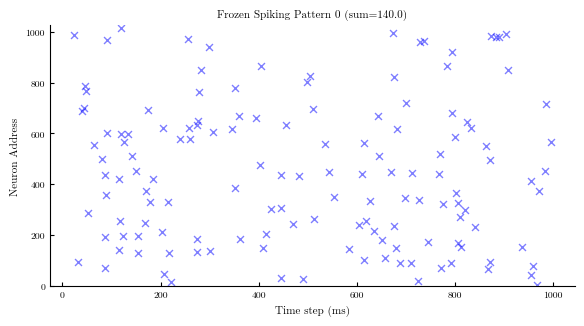

In [7]:
fig, ax = plt.subplots()
splt.raster(pattern[opt.i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, facecolor='blue', edgecolor='none',  marker='x', alpha=.5)
ax.set_xlabel("Time step (ms)")
ax.set_ylabel("Neuron Address")
ax.set_ylim(-1., opt.N_neuron_show + 1.)
ax.set_title(f"Frozen Spiking Pattern {opt.i_pattern} (sum={pattern[opt.i_pattern, :, :].sum().item()})")
printfig(fig, 'ssp_frozen_pattern', fig_width=opt.fig_width, fig_height=opt.fig_height, figpath=figpath)

pattern.shape, pattern[opt.i_pattern, :opt.N_neuron_show, :opt.N_time_show].sum().item(), pattern[opt.i_pattern, :, :].sum().item()

## The stochastic pattern generator (`StochasticSpikingPattern`)

A *realisation* is produced by **balanced bit flipping** (see the `flip_bits` function in `mnesis_boilerplate.py`):
each entry of the frozen target is selected with probability `p_flip`; a selected entry is then
*re-sampled* from `Bernoulli(mean(raster))` rather than simply negated. The marginal rate is
thus preserved while the spatio-temporal structure is decorrelated. These realisations are
the data augmentation of the training loop (notebook 11) and the retrieval-noise probe of
notebooks 14-16.

TODO : use a LIF to filter the signal in order to get more realistic spiking patterns

In [8]:
# Fresh Params + fresh generator: init() re-draws the frozen target from the same seed,
# so this is the same memory trace as sp.frozen_target; only the realisations vary.
opt = Params()
ssp = StochasticSpikingPattern()
print(f'Description: {ssp.desc}')
ssp.init(opt, verbose=DEBUG)

Description: Stochastic spike pattern generator
Target pattern generated with shape torch.Size([16, 1024, 1000]) and mean 1.579e-04


In [9]:
# The frozen target is a 0/1 tensor whose mean is the empirical firing rate (~p_A).
frozen_target = ssp.frozen_target
frozen_target.shape, frozen_target.min().item(), frozen_target.max().item(), frozen_target.mean().item()

(torch.Size([16, 1024, 1000]), 0.0, 1.0, 0.0001578979572514072)

Showing the target pattern (should not change when calling the generative model):

In [10]:
if DEBUG >1:


    fig, ax = plt.subplots()
    splt.raster(frozen_target[opt.i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, facecolor='blue', edgecolor='none',  marker='x', alpha=.5)
    ax.set_xlabel("Time step (ms)")
    ax.set_ylabel("Neuron Address")
    ax.set_ylim(-1., opt.N_neuron_show + 1.)
    ax.set_title(f"One instance of a Stochastic Spiking Pattern {ssp.opt.p_flip=:.2f} ")
    printfig(fig, 'ssp_frozen_pattern', fig_width=opt.fig_width, fig_height=opt.fig_height, figpath=figpath)
    frozen_target.shape, frozen_target[opt.i_pattern, :opt.N_neuron_show, :opt.N_time_show].sum().item(), frozen_target[opt.i_pattern, :, :].sum().item()

In [11]:
ssp.opt.p_flip

0.01

Draw two instances of a pattern:

### Sensitivity of the realisations to `p_flip`

Sweep of `p_flip` from 0 (faithful copy of the frozen target) to 1 (target fully re-randomised
while keeping its rate). Because the flip is *balanced*, the total spike count stays constant
across the sweep - only the overlap with the frozen target decays.

In [12]:
if DEBUG >1:
    # verification that out frequency is kept constant while the pattern is stochastically modified
    for p_flip in np.linspace(0.0, 1.0, 13):
        print(f'{p_flip=:2e}', end=' - ')
        opt = Params(p_flip=p_flip)
        ssp = StochasticSpikingPattern()
        ssp.init(opt, verbose=False)
        print(f'p_flip={p_flip:.2e} (={ssp.opt.p_flip:.2e}) - Spike count: {ssp.frozen_target.sum().item():.2f} spikes, mean={ssp.frozen_target.mean().item():.3e}')


### Two realisations of the same motif

`verbose=True` prints, for each draw, how many bits were selected for flipping and the rate
*before* vs *after* a naive toggle: the logged `1.605e-04 -> 1.002e-01` is what the rate
*would* become if selected bits were simply inverted - the returned tensor instead re-samples
selected bits from `Bernoulli(mean)`, so the rate stays at `p_A`.

Markers: solid blue `x` = first realisation, open red `o` = second realisation of the same motif.

Target pattern generated with shape torch.Size([16, 1024, 1000]) and mean 1.579e-04
Flipping 1637667.0 bits out of 16384000 (p_flip=0.1, flip seed=323672769044698978), 1.579e-04 -> 1.001e-01
Flipping 1640305.0 bits out of 16384000 (p_flip=0.1, flip seed=15924531995448135257), 1.579e-04 -> 1.002e-01
Saving as ../figures/ssp_two_frozen_pattern.pdf
Saving as ../figures/ssp_two_frozen_pattern.png
Saving as ../figures/ssp_two_frozen_pattern.svg


/Users/laurentperrinet/sdrive_cnrs/hot_from_git/TemporallyHeterogeneousConnections/MNESIS/.venv/lib/python3.12/site-packages/snntorch/spikeplot.py:120: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  return ax.scatter(*torch.where(data.cpu()), **kwargs)
/Users/laurentperrinet/sdrive_cnrs/hot_from_git/TemporallyHeterogeneousConnections/MNESIS/.venv/lib/python3.12/site-packages/snntorch/spikeplot.py:120: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  return ax.scatter(*torch.where(data.cpu()), **kwargs)


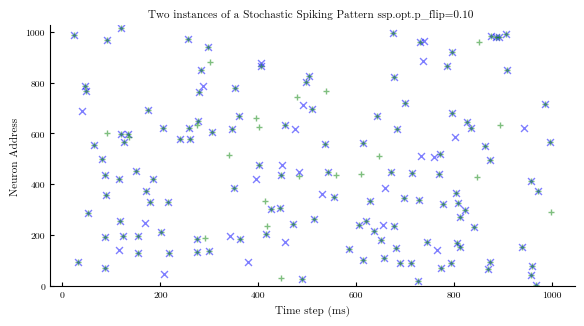

In [13]:
if True: #DEBUG > 0:

    opt = Params(p_flip=.1)
    ssp = StochasticSpikingPattern()
    ssp.init(opt, verbose=DEBUG)

      # two independent realisations of the *same* frozen motif (verbose logs the flips)
    pattern = ssp(verbose=True)
    pattern2 = ssp(verbose=True)

    fig, ax = plt.subplots()
    splt.raster(pattern[opt.i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, facecolor='blue', edgecolor='none',  marker='x', alpha=.5)
    splt.raster(pattern2[opt.i_pattern, :opt.N_neuron_show, :opt.N_time_show].T, ax, s=25, facecolor='green', edgecolor='none',  marker='+', alpha=.5)
    ax.set_xlabel("Time step (ms)")
    ax.set_ylabel("Neuron Address")
    ax.set_ylim(-1., opt.N_neuron_show + 1.)
    ax.set_title(f"Two instances of a Stochastic Spiking Pattern {ssp.opt.p_flip=:.2f} ")
    printfig(fig, 'ssp_two_frozen_pattern', fig_width=opt.fig_width, fig_height=opt.fig_height, figpath=figpath)
    pattern2.shape, pattern2[opt.i_pattern, :opt.N_neuron_show, :opt.N_time_show].sum().item(), pattern2[opt.i_pattern, :, :].sum().item()